⏳ Зареждане на данни...


[*********************100%***********************]  1 of 1 completed


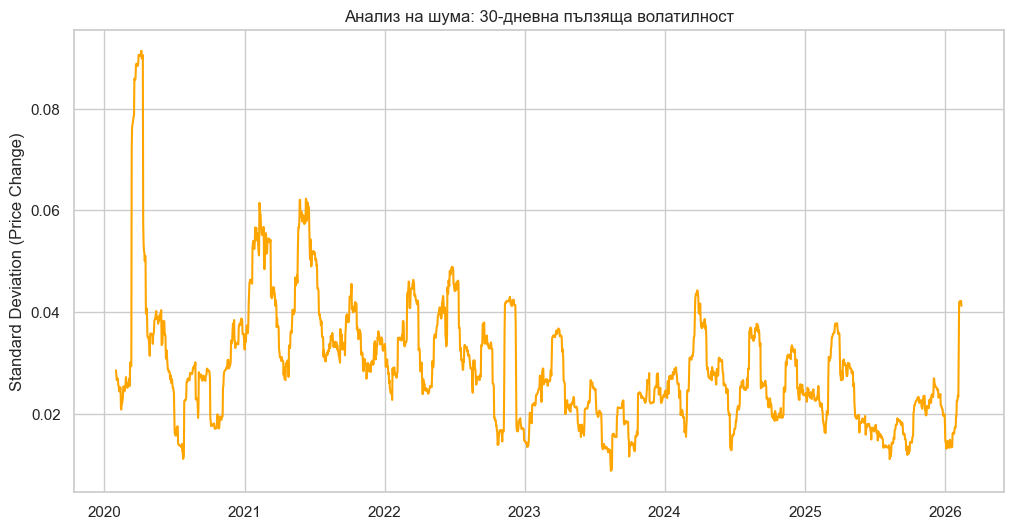


=== Анализ на дисбаланс (Representativeness) ===
Is_Anomaly
False    2015
True      220
Name: count, dtype: int64
Процент аномалии: 9.84%


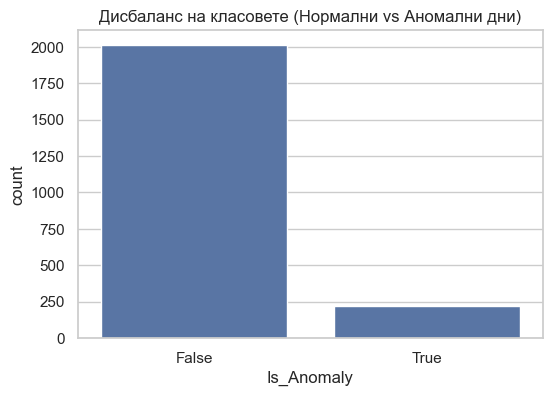

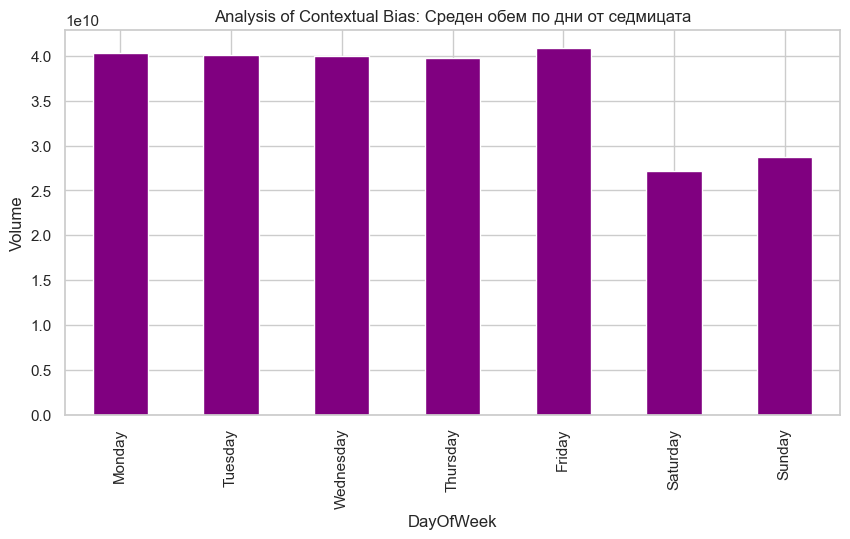


=== Non-Model Defined Baseline (Naive Approach) ===
Хипотеза: 'Цената утре ще е равна на цената днес'.
Baseline MAE (Средна грешка в долари): $961.10
Baseline RMSE: $1522.60
Цел на ML модела: Да постигне MAE по-ниско от Baseline стойността.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import mean_absolute_error, mean_squared_error
import yfinance as yf

# Настройки
sns.set(style="whitegrid")
SYMBOL = 'BTC-USD'
START = '2020-01-01'

# 1. Зареждане на данни
print("⏳ Зареждане на данни...")
df = yf.download(SYMBOL, start=START)
if isinstance(df.columns, pd.MultiIndex):
    df.columns = df.columns.get_level_values(0)

# --- КРИТЕРИЙ 1: Анализ на шум (Noise Analysis) ---
# Изчисляване на волатилност (Rolling Std Dev)
df['Volatility_30d'] = df['Close'].pct_change().rolling(window=30).std()

plt.figure(figsize=(12, 6))
plt.plot(df.index, df['Volatility_30d'], color='orange')
plt.title('Анализ на шума: 30-дневна пълзяща волатилност')
plt.ylabel('Standard Deviation (Price Change)')
plt.show()

# --- КРИТЕРИЙ 2: Анализ на дисбаланс (Class Imbalance) ---
# Дефинираме "Аномалия" като ден с промяна > 5% (примерно)
df['Daily_Change_Pct'] = df['Close'].pct_change().abs()
THRESHOLD = 0.05
df['Is_Anomaly'] = df['Daily_Change_Pct'] > THRESHOLD

anomaly_counts = df['Is_Anomaly'].value_counts()
print("\n=== Анализ на дисбаланс (Representativeness) ===")
print(anomaly_counts)
print(f"Процент аномалии: {(anomaly_counts[True] / len(df) * 100):.2f}%")

plt.figure(figsize=(6, 4))
sns.countplot(x=df['Is_Anomaly'])
plt.title('Дисбаланс на класовете (Нормални vs Аномални дни)')
plt.show()

# --- КРИТЕРИЙ 3: Времеви отклонения (Temporal Bias) ---
# Проверка дали денят от седмицата влияе на обема (Weekend Effect)
df['DayOfWeek'] = df.index.day_name()
avg_volume_by_day = df.groupby('DayOfWeek')['Volume'].mean().reindex(
    ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
)

plt.figure(figsize=(10, 5))
avg_volume_by_day.plot(kind='bar', color='purple')
plt.title('Analysis of Contextual Bias: Среден обем по дни от седмицата')
plt.ylabel('Volume')
plt.show()

# --- КРИТЕРИЙ 6: Критерии за успех (Baseline Model) ---
# Naive Approach: Цената утре ще е същата като днес.
# y_true (Утре) vs y_pred (Днес)
y_true = df['Close'][1:]
y_pred_naive = df['Close'][:-1] # Shift-нат ред

mae_naive = mean_absolute_error(y_true, y_pred_naive)
rmse_naive = np.sqrt(mean_squared_error(y_true, y_pred_naive))

print("\n=== Non-Model Defined Baseline (Naive Approach) ===")
print(f"Хипотеза: 'Цената утре ще е равна на цената днес'.")
print(f"Baseline MAE (Средна грешка в долари): ${mae_naive:.2f}")
print(f"Baseline RMSE: ${rmse_naive:.2f}")
print("Цел на ML модела: Да постигне MAE по-ниско от Baseline стойността.")S